# Step 8 — Hop-survival thesis figures

Produces the **two** figures the thesis needs from data that already exists:

1. **Figure 1 — hop-position decay** (`hop_survival_decay.pdf`): mean raw similarity to the anchor by hop (top), and per-configuration survival rate by hop with each configuration's random baseline (bottom).
2. **Figure 2 — survival by anchor density** (`hop_survival_by_density.pdf`): Kneedle S=1.0 survival by hop, split into three basket-count strata.

Inputs are read from `outputs/hop_survival_summary.json` (written by `07_hop_survival_analysis.ipynb`); anything missing there is recomputed from `outputs/full_scale/walk_raw_paths.jsonl`, the six `outputs/full_scale/filters/*/*/thresholds.json`, and `outputs/full_scale/product_basket_freq.json` using notebook 07's own definitions.

Nothing here regenerates walks, filters, or models. **Author-only — run to produce the PDFs/PNGs.**

## Provenance — read vs recompute

The summary file contains all five quantities these figures need (`analysis1_similarity_by_hop.mean`, `analysis2_survival_by_hop`, `analysis3_baseline`, `analysis5_stratified_kneedle_1.0` survival + sizes), so on the current data **every quantity is read from the summary JSON**. The recompute paths below are a fallback for a missing/older summary and mirror notebook 07's definitions exactly. The loader prints a per-quantity `read` / `recomputed` report so the provenance is explicit at run time.

## 1. Imports, paths, and style

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt   # matplotlib only, no seaborn
from matplotlib.lines import Line2D

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = ROOT / "outputs"
FULL_SCALE_DIR = OUT_DIR / "full_scale"
FILTERS_DIR = FULL_SCALE_DIR / "filters"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = OUT_DIR / "hop_survival_summary.json"
WALK_PATH = FULL_SCALE_DIR / "walk_raw_paths.jsonl"
FREQ_PATH = FULL_SCALE_DIR / "product_basket_freq.json"

# ---- Thesis figure style (9pt ticks, 10pt labels; fonts embedded for LaTeX) ----
mpl.rcParams.update({
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.labelsize": 10, "legend.fontsize": 8, "font.size": 9,
    "axes.linewidth": 0.8, "lines.linewidth": 1.3, "lines.markersize": 4,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # TrueType, not Type-3 -> editable/selectable text
    "savefig.bbox": "tight", "figure.dpi": 110,
})
FIG_WIDTH = 6.5   # inches — thesis text width

# ---- The six configurations: internal label -> (folder), + thesis display name ----
CONFIGS = [
    ("pct_dropoff (0.03)", "pct_dropoff", "drop_0.03"),
    ("pct_dropoff (0.05)", "pct_dropoff", "drop_0.05"),
    ("pct_dropoff (0.10)", "pct_dropoff", "drop_0.10"),
    ("kneedle (0.3)",      "kneedle",     "sensitivity_0.3"),
    ("kneedle (0.5)",      "kneedle",     "sensitivity_0.5"),
    ("kneedle (1.0)",      "kneedle",     "sensitivity_1.0"),
]
LABELS = [c[0] for c in CONFIGS]
FOLDER = {c[0]: (c[1], c[2]) for c in CONFIGS}


def thesis_name(label):
    """Internal label -> thesis display name (never the folder name)."""
    value = label.split("(")[1].rstrip(")")
    if label.startswith("pct_dropoff"):
        return f"Drop-off $\\delta$={value}"
    if label.startswith("kneedle"):
        return f"Kneedle $S$={value}"
    return label


def short(label):
    """Compact ASCII header for the printed numeric tables."""
    value = label.split("(")[1].rstrip(")")
    return ("Drop " if label.startswith("pct_dropoff") else "Knee ") + value


# Grayscale-safe: distinct color AND line style AND marker per configuration.
STYLE = {
    "pct_dropoff (0.03)": dict(color="#1f77b4", ls="-",             marker="o"),
    "pct_dropoff (0.05)": dict(color="#ff7f0e", ls="--",            marker="s"),
    "pct_dropoff (0.10)": dict(color="#2ca02c", ls="-.",            marker="^"),
    "kneedle (0.3)":      dict(color="#d62728", ls=":",             marker="D"),
    "kneedle (0.5)":      dict(color="#9467bd", ls=(0, (3, 1, 1, 1)), marker="v"),
    "kneedle (1.0)":      dict(color="#8c564b", ls=(0, (5, 1)),     marker="P"),
}
print("figures dir:", FIG_DIR)

figures dir: /Users/linnhtet/Developer/bachelor-thesis/outputs/figures


## 2. Load the summary, recompute anything missing, report provenance

In [2]:
SUMMARY = json.loads(SUMMARY_PATH.read_text()) if SUMMARY_PATH.exists() else {}
provenance = {}
_walk_cache = {}


def _walk_matrix():
    """Lazy: NaN-padded (N, HOPS) raw_sims matrix + mask + anchor ids (notebook 07)."""
    if "M" not in _walk_cache:
        anchor_ids, sims_lists = [], []
        with open(WALK_PATH) as f:
            for line in f:
                r = json.loads(line)
                anchor_ids.append(int(r["anchor_id"]))
                sims_lists.append(r["raw_sims"])          # raw_sims[i] -> hop i+1
        H = max(len(s) for s in sims_lists)
        M = np.full((len(sims_lists), H), np.nan, dtype=np.float32)
        for i, s in enumerate(sims_lists):
            if s:
                M[i, :len(s)] = s
        _walk_cache.update(M=M, mask=~np.isnan(M),
                           anchor=np.asarray(anchor_ids, dtype=np.int64), H=H)
    return _walk_cache


def _thetas(label):
    method, vf = FOLDER[label]
    raw = json.loads((FILTERS_DIR / method / vf / "thresholds.json").read_text())
    return {int(a): t["theta"] for a, t in raw.items()}


def _survival(label, row_sel=None):
    """Survival rate per hop for one config (notebook 07 definition)."""
    w = _walk_matrix(); M, mask, anchor, H = w["M"], w["mask"], w["anchor"], w["H"]
    d = _thetas(label)
    tv = np.array([d.get(a, np.nan) for a in anchor], dtype=np.float64)
    valid = ~np.isnan(tv)
    sel = valid if row_sel is None else (valid & row_sel)
    m = mask[sel]
    cleared = (M[sel] >= tv[sel][:, None]) & m
    tot, sv = m.sum(axis=0), cleared.sum(axis=0)
    return np.divide(sv, tot, out=np.full(H, np.nan), where=tot > 0)


# ---- Quantity 1: mean similarity by hop ----
a1 = SUMMARY.get("analysis1_similarity_by_hop") or {}
if a1.get("mean") is not None and a1.get("hop") is not None:
    provenance["mean_similarity"] = "read"
    hops = list(a1["hop"]); mean_sim = np.asarray(a1["mean"], dtype=float)
else:
    provenance["mean_similarity"] = "recomputed"
    w = _walk_matrix(); hops = list(range(1, w["H"] + 1)); mean_sim = np.nanmean(w["M"], axis=0)
HOPS = len(hops); hop_x = np.asarray(hops)

# ---- Quantity 2: per-config survival by hop ----
a2 = SUMMARY.get("analysis2_survival_by_hop") or {}
survival = {}
if all(lab in a2 for lab in LABELS):
    provenance["survival"] = "read"
    survival = {lab: np.asarray([np.nan if v is None else v for v in a2[lab]], float) for lab in LABELS}
else:
    provenance["survival"] = "recomputed"
    survival = {lab: _survival(lab) for lab in LABELS}

# ---- Quantity 3: per-config random baseline ----
a3 = SUMMARY.get("analysis3_baseline") or {}
if all(lab in a3 for lab in LABELS):
    provenance["baseline"] = "read"
    baseline = {lab: float(a3[lab]) for lab in LABELS}
else:
    provenance["baseline"] = "recomputed"   # mirrors notebook 07 (needs Phase-1 vectors)
    def _emb_path(*names):
        for n in names:
            if (OUT_DIR / n).exists(): return OUT_DIR / n
            if (OUT_DIR / "step1" / n).exists(): return OUT_DIR / "step1" / n
        raise FileNotFoundError(names)
    emb = np.load(_emb_path("embeddings.npy")).astype(np.float32)
    emb = emb / np.clip(np.linalg.norm(emb, axis=1, keepdims=True), 1e-12, None)
    pid_to_idx = {int(p): i for p, i in json.loads(_emb_path("product_id_to_index.json").read_text()).items()}
    Ncat = emb.shape[0]
    seed = (SUMMARY.get("meta") or {}).get("baseline_seed", 23)
    n_samp = (SUMMARY.get("meta") or {}).get("baseline_sample", 2000)
    w = _walk_matrix(); rng = np.random.default_rng(seed)
    uniq = np.unique(w["anchor"]); samp = rng.choice(uniq, size=min(n_samp, len(uniq)), replace=False)
    fr = {lab: [] for lab in LABELS}; thr = {lab: _thetas(lab) for lab in LABELS}
    for a in samp:
        a = int(a)
        if a not in pid_to_idx: continue
        sims = emb @ emb[pid_to_idx[a]]; sims[pid_to_idx[a]] = -np.inf
        for lab in LABELS:
            th = thr[lab].get(a)
            if th is not None:
                fr[lab].append(float((sims >= th).sum()) / (Ncat - 1))
    baseline = {lab: (float(np.mean(v)) if v else float("nan")) for lab, v in fr.items()}

# ---- Quantity 4: kneedle 1.0 stratified survival + stratum sizes ----
a5 = SUMMARY.get("analysis5_stratified_kneedle_1.0") or {}
STRATA = [("thin", 0, 50), ("medium", 50, 1000), ("dense", 1000, np.inf)]
if a5.get("survival_by_hop") and a5.get("sizes"):
    provenance["stratified"] = "read"
    strat_surv = {nm: np.asarray([np.nan if v is None else v for v in a5["survival_by_hop"][nm]], float)
                  for nm, _, _ in STRATA}
    strat_size = {nm: a5["sizes"][nm] for nm, _, _ in STRATA}
else:
    provenance["stratified"] = "recomputed"
    with open(FREQ_PATH) as f:
        bc = {int(p): v for p, v in json.load(f)["product_basket_count"].items()}
    w = _walk_matrix(); bc_arr = np.array([bc.get(a, 0) for a in w["anchor"]])
    strat_surv, strat_size = {}, {}
    for nm, lo, hi in STRATA:
        sel = (bc_arr >= lo) & (bc_arr < hi)
        strat_surv[nm] = _survival("kneedle (1.0)", row_sel=sel)
        strat_size[nm] = {"walks": int(sel.sum()),
                          "distinct_anchors": int(np.unique(w["anchor"][sel]).size)}

print("Provenance (per quantity):")
for k, v in provenance.items():
    print(f"  {k:<16} : {v}")
print(f"\nhops = 1..{HOPS}")
print("baselines:", {thesis_name(l): round(baseline[l], 6) for l in LABELS})

Provenance (per quantity):
  mean_similarity  : read
  survival         : read
  baseline         : read
  stratified       : read

hops = 1..15
baselines: {'Drop-off $\\delta$=0.03': 0.000411, 'Drop-off $\\delta$=0.05': 0.000669, 'Drop-off $\\delta$=0.10': 0.000926, 'Kneedle $S$=0.3': 0.001254, 'Kneedle $S$=0.5': 0.001456, 'Kneedle $S$=1.0': 0.005891}


## Figure 1 — hop-position decay

Top: threshold-independent mean similarity to the anchor (one line). Bottom: per-configuration survival rate with each configuration's random baseline (dashed, same color). The bottom y-axis scale is chosen from the data (see the comment).

survival panel y-scale: log (dynamic range 408x)


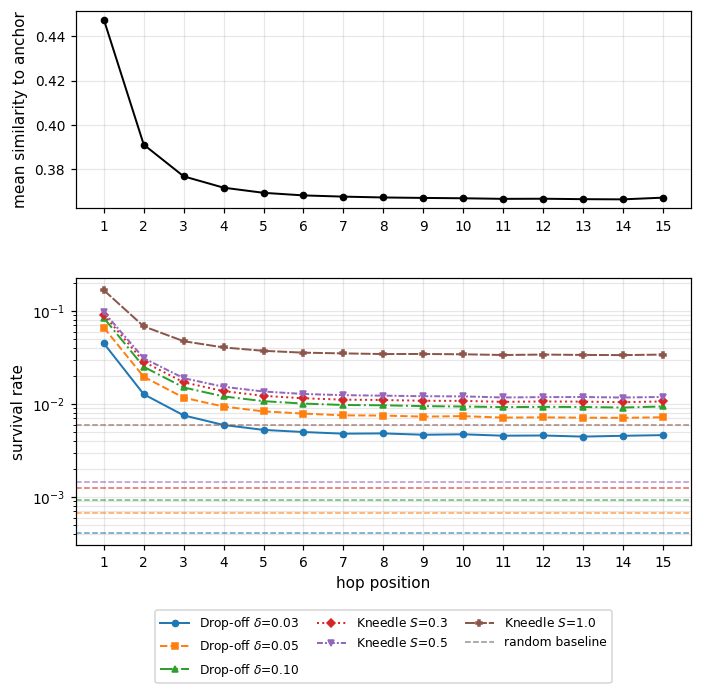

Saved: hop_survival_decay.pdf + .png (200 dpi)

FIGURE 1 data
 hop  mean_sim    Drop 0.03    Drop 0.05    Drop 0.10     Knee 0.3     Knee 0.5     Knee 1.0
   1    0.4477      0.04493      0.06630      0.08426      0.09160      0.09749      0.16745
   2    0.3909      0.01274      0.01963      0.02514      0.02847      0.03108      0.06841
   3    0.3765      0.00755      0.01170      0.01507      0.01713      0.01897      0.04739
   4    0.3713      0.00595      0.00939      0.01207      0.01377      0.01532      0.04060
   5    0.3690      0.00527      0.00834      0.01074      0.01226      0.01364      0.03735
   6    0.3678      0.00500      0.00790      0.01012      0.01152      0.01283      0.03568
   7    0.3673      0.00480      0.00756      0.00977      0.01116      0.01246      0.03504
   8    0.3669      0.00483      0.00752      0.00970      0.01105      0.01231      0.03449
   9    0.3667      0.00468      0.00733      0.00950      0.01085      0.01214      0.03454
  10    

In [3]:
# ---- y-scale decision for the survival panel ----
# The six baselines (~4e-4 .. 6e-3) are two-plus orders of magnitude below the
# hop-1 survival (~0.05 .. 0.17). On a linear axis they would all collapse onto
# zero and be mutually indistinguishable, so we use a LOG y-axis whenever the
# dynamic range of the plotted values exceeds ~50x. (On the current data the
# ratio is ~400x, so this selects log.)
_vals = [v for lab in LABELS for v in survival[lab] if v is not None and v > 0]
_vals += [baseline[lab] for lab in LABELS if baseline[lab] > 0]
USE_LOG = (max(_vals) / min(_vals)) > 50
print(f"survival panel y-scale: {'log' if USE_LOG else 'linear'} "
      f"(dynamic range {max(_vals) / min(_vals):.0f}x)")

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(FIG_WIDTH, 6.0),
    gridspec_kw={"height_ratios": [1, 1.35], "hspace": 0.30})

# ---- Top: mean similarity to anchor (single line) ----
ax_top.plot(hop_x, mean_sim, color="black", ls="-", marker="o", markersize=4)
ax_top.set_ylabel("mean similarity to anchor")
ax_top.set_xticks(hop_x)
ax_top.tick_params(labelbottom=True)     # show the 1..15 hop ticks on the upper panel too
ax_top.grid(alpha=0.3)                    # Analysis-3 grid styling

# ---- Bottom: survival rate per config + baselines (Analysis-3 styling) ----
handles = []
for lab in LABELS:
    st = STYLE[lab]
    y = np.array([np.nan if (v is None) else v for v in survival[lab]], float)
    if USE_LOG:
        y = np.where(y > 0, y, np.nan)      # log-safe: drop non-positive points
    (h,) = ax_bot.plot(hop_x, y, color=st["color"], ls=st["ls"], marker=st["marker"],
                       markersize=4, label=thesis_name(lab))
    handles.append(h)
    # baseline: dashed, same color, matching Analysis 3 (ls="--", lw=1, alpha=0.7)
    ax_bot.axhline(baseline[lab], color=st["color"], ls="--", lw=1, alpha=0.7)
if USE_LOG:
    ax_bot.set_yscale("log")
ax_bot.set_xlabel("hop position")
ax_bot.set_ylabel("survival rate")
ax_bot.set_xticks(hop_x)
ax_bot.grid(alpha=0.3, which="both")      # Analysis-3 grid styling (both = log minor lines)

# proxy so the reader knows the dashed lines are the per-config random baselines
baseline_proxy = Line2D([], [], color="0.4", ls="--", lw=1, alpha=0.7,
                        label="random baseline")

# ---- legend: framed (Analysis-3 style), placed BELOW the lower panel, clear of
# the x-tick labels and the "hop position" axis title (i.e. out of the plot area).
ax_bot.legend(handles + [baseline_proxy],
              [h.get_label() for h in handles] + ["random baseline"],
              loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3,
              frameon=True, handlelength=2.4, columnspacing=1.4)

# Reserve margins explicitly (tight_layout warns with legends outside the axes);
# savefig.bbox="tight" (set in rcParams) captures the below-axes legend in the file.
fig.subplots_adjust(left=0.11, right=0.97, top=0.97, bottom=0.16, hspace=0.30)

fig.savefig(FIG_DIR / "hop_survival_decay.pdf")          # vector
fig.savefig(FIG_DIR / "hop_survival_decay.png", dpi=200)  # raster preview
plt.show()
print("Saved:", (FIG_DIR / "hop_survival_decay.pdf").name, "+ .png (200 dpi)")

# ---- underlying numbers (so the figure can be checked against the thesis text) ----
print("\nFIGURE 1 data")
hdr = f"{'hop':>4}{'mean_sim':>10}" + "".join(f"{short(l):>13}" for l in LABELS)
print(hdr)
for i in range(HOPS):
    row = f"{hop_x[i]:>4}{mean_sim[i]:>10.4f}"
    for lab in LABELS:
        v = survival[lab][i]
        row += f"{('nan' if v is None or (isinstance(v, float) and np.isnan(v)) else f'{v:.5f}'):>13}"
    print(row)
print(f"{'base':>4}{'':>10}" + "".join(f"{baseline[l]:>13.5f}" for l in LABELS))

## Figure 2 — survival by anchor density

Kneedle S=1.0 only, survival by hop split by the anchor's basket count into three strata. Legend reports the number of anchors in each stratum.

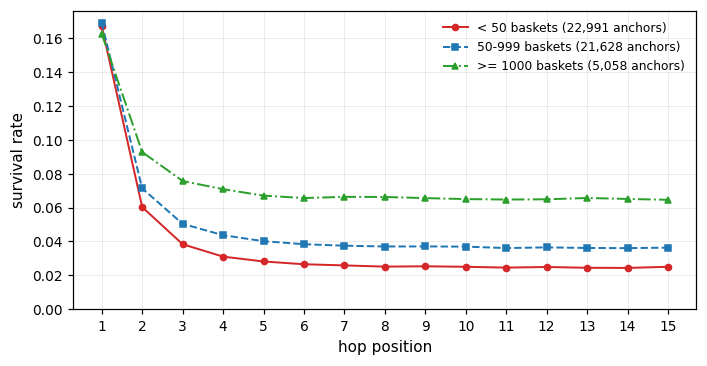

Saved: hop_survival_by_density.pdf + .png (200 dpi)

FIGURE 2 data (Kneedle S=1.0, survival rate by hop)
 hop        thin      medium       dense
   1     0.16706     0.16901     0.16261
   2     0.06029     0.07133     0.09278
   3     0.03835     0.05039     0.07567
   4     0.03103     0.04369     0.07086
   5     0.02818     0.04015     0.06705
   6     0.02654     0.03838     0.06563
   7     0.02585     0.03749     0.06632
   8     0.02513     0.03702     0.06626
   9     0.02533     0.03706     0.06559
  10     0.02504     0.03694     0.06501
  11     0.02455     0.03609     0.06475
  12     0.02492     0.03650     0.06489
  13     0.02445     0.03615     0.06566
  14     0.02437     0.03605     0.06510
  15     0.02504     0.03634     0.06459

stratum sizes:
  < 50 baskets     walks=   459,820  distinct_anchors=  22,991
  50-999 baskets   walks=   432,560  distinct_anchors=  21,628
  >= 1000 baskets  walks=   101,160  distinct_anchors=   5,058


In [4]:
STRAT_STYLE = {
    "thin":   dict(color="#d62728", ls="-",  marker="o", disp="< 50 baskets"),
    "medium": dict(color="#1f77b4", ls="--", marker="s", disp="50-999 baskets"),
    "dense":  dict(color="#2ca02c", ls="-.", marker="^", disp=">= 1000 baskets"),
}

fig2, ax = plt.subplots(figsize=(FIG_WIDTH, 3.4))
for nm, _, _ in STRATA:
    st = STRAT_STYLE[nm]
    n_anch = strat_size[nm].get("distinct_anchors", strat_size[nm].get("walks"))
    ax.plot(hop_x, strat_surv[nm], color=st["color"], ls=st["ls"], marker=st["marker"],
            markersize=4, label=f"{st['disp']} ({n_anch:,} anchors)")
# survival here spans ~0.02..0.17 (dynamic range ~8x), readable on a linear axis.
ax.set_xlabel("hop position")
ax.set_ylabel("survival rate")
ax.set_xticks(hop_x)
ax.set_ylim(0, None)
ax.grid(alpha=0.3, linewidth=0.5)
ax.legend(frameon=False, loc="upper right")
fig2.tight_layout()

fig2.savefig(FIG_DIR / "hop_survival_by_density.pdf")           # vector
fig2.savefig(FIG_DIR / "hop_survival_by_density.png", dpi=200)   # raster preview
plt.show()
print("Saved:", (FIG_DIR / "hop_survival_by_density.pdf").name, "+ .png (200 dpi)")

# ---- underlying numbers ----
print("\nFIGURE 2 data (Kneedle S=1.0, survival rate by hop)")
print(f"{'hop':>4}{'thin':>12}{'medium':>12}{'dense':>12}")
for i in range(HOPS):
    print(f"{hop_x[i]:>4}{strat_surv['thin'][i]:>12.5f}"
          f"{strat_surv['medium'][i]:>12.5f}{strat_surv['dense'][i]:>12.5f}")
print("\nstratum sizes:")
for nm, _, _ in STRATA:
    s = strat_size[nm]
    print(f"  {STRAT_STYLE[nm]['disp']:<16} walks={s.get('walks','?'):>10,}  "
          f"distinct_anchors={s.get('distinct_anchors','?'):>8,}")